# Hyperspectral Image Classification with CNN and Transformer

**Author:** Alessandro Carotenuto  
**Student ID:** 1847282  
**Dataset:** Pavia University  

## Project aim

The project aims to classify land-cover pixels in a hyperspectral image.
A spatial-spectral patch centered on each labeled pixel is used as input.
A CNN learns local features, while a lightweight Transformer models non-local context.

## Setup 

### Experiment Configuration

In [55]:
# Standard library imports
from pathlib import Path
import sys

# Third-party imports
import numpy as np
import torch
import torch.nn as nn
from scipy.io import loadmat

# Project paths and local imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data import (
    collect_coordinates_by_class,
    count_padding_requirements,
    create_dataloaders,
    create_few_shot_split,
    create_patch_datasets,
    extract_patch,
    normalize_per_band_min_max,
    reflect_pad_spatially,
    save_and_verify_split,
    split_counts_by_class,
    verify_few_shot_split,
)
from evaluation import (
    build_classification_map,
    build_evaluation_report,
    evaluate_checkpoint,
    save_evaluation_report,
)
from models import CNNOnlyBaseline, MultiscaleCNNBlock
from plotting import (
    plot_class_distribution,
    plot_classification_map,
    plot_confusion_matrix,
    plot_mean_spectral_signatures,
    plot_spectral_bands_and_ground_truth,
    plot_training_curves,
)
from training import (
    build_checkpoint_path,
    configure_reproducibility,
    fit_model,
    run_small_batch_overfit_check,
)
from utils import (
    DataSplitType,
    LRSchedulingType,
    PatchSize,
    PaviaClass,
    RunMode,
    SplitName,
)

data_dir = project_root / "data" / "raw"
cube_path = data_dir / "PaviaU.mat"
ground_truth_path = data_dir / "PaviaU_gt.mat"

# Dataset and few-shot split
SPLIT_SEED = 42
DATA_SPLIT_TYPE = DataSplitType.RANDOM
TRAIN_SAMPLES_PER_CLASS = 10
VALIDATION_SAMPLES_PER_CLASS = 5
NUM_CLASSES = len(PaviaClass) - 1
LABELED_CLASS_IDS = tuple(
    int(label) for label in PaviaClass
    if label != PaviaClass.UNLABELED
)
SPLIT_NAMES = tuple(split_name.value for split_name in SplitName)
class_names = {
    int(label): label.display_name for label in PaviaClass
}

# Patch extraction and visualisation
PATCH_SIZE = PatchSize.PAPER
PATCH_RADIUS = int(PATCH_SIZE) // 2
BANDS_TO_SHOW = (10, 50, 90)

# Data loading
BATCH_SIZE = 32
NUM_WORKERS = 0
TRAINING_SEED = 100

# Model
FEATURE_CHANNELS = 128

# Training
EPOCHS = 150
SMOKE_TEST_EPOCHS = 3
RUN_FULL_TRAINING = True
LEARNING_RATE = 0.00008
LR_SCHEDULING = LRSchedulingType.FIXED
EVALUATION_PROGRESS_EVERY = 100
SAVE_EVALUATION_REPORT = True

# Small-batch overfitting check
OVERFIT_LEARNING_RATE = 0.003
OVERFIT_MIN_STEPS = 50
OVERFIT_MAX_STEPS = 250
OVERFIT_TARGET_LOSS = 0.05

print("Cube:", cube_path)
print("Ground truth:", ground_truth_path)
print("Patch size:", int(PATCH_SIZE))
print("Split seed:", SPLIT_SEED)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Training seed:", TRAINING_SEED)
print("Run mode:", RunMode.FULL if RUN_FULL_TRAINING else RunMode.SMOKE)

Cube: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU.mat
Ground truth: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU_gt.mat
Patch size: 15
Split seed: 1
Data split: random_no_overlap
Training seed: 100
Run mode: full


### Loading MATLAB Files

In [56]:
cube_file = loadmat(cube_path)
ground_truth_file = loadmat(ground_truth_path)

print(cube_file.keys())
print(ground_truth_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


### Dimension Check

In [57]:
cube = cube_file["paviaU"]
ground_truth = ground_truth_file["paviaU_gt"]

print("Cube:", cube.shape, cube.dtype)
print("Ground truth:", ground_truth.shape, ground_truth.dtype)
print("Cube range:", cube.min(), cube.max())
print("Labels:", np.unique(ground_truth))

Cube: (610, 340, 103) uint16
Ground truth: (610, 340) uint8
Cube range: 0 8000
Labels: [0 1 2 3 4 5 6 7 8 9]


### Class Count

In [58]:
labels, counts = np.unique(ground_truth, return_counts=True)

for label, count in zip(labels, counts):
    print(label, class_names[label], count)

0 Unlabeled 164624
1 Asphalt 6631
2 Meadows 18649
3 Gravel 2099
4 Trees 3064
5 Painted metal sheets 1345
6 Bare Soil 5029
7 Bitumen 1330
8 Self-Blocking Bricks 3682
9 Shadows 947


### Active Patch Shape

In [59]:
print("Patch size:", int(PATCH_SIZE))
print("Patch radius:", PATCH_RADIUS)

Patch size: 15
Patch radius: 7


## Dataset Exploration and Dataloaders

### Spectral Bands and Ground Truth

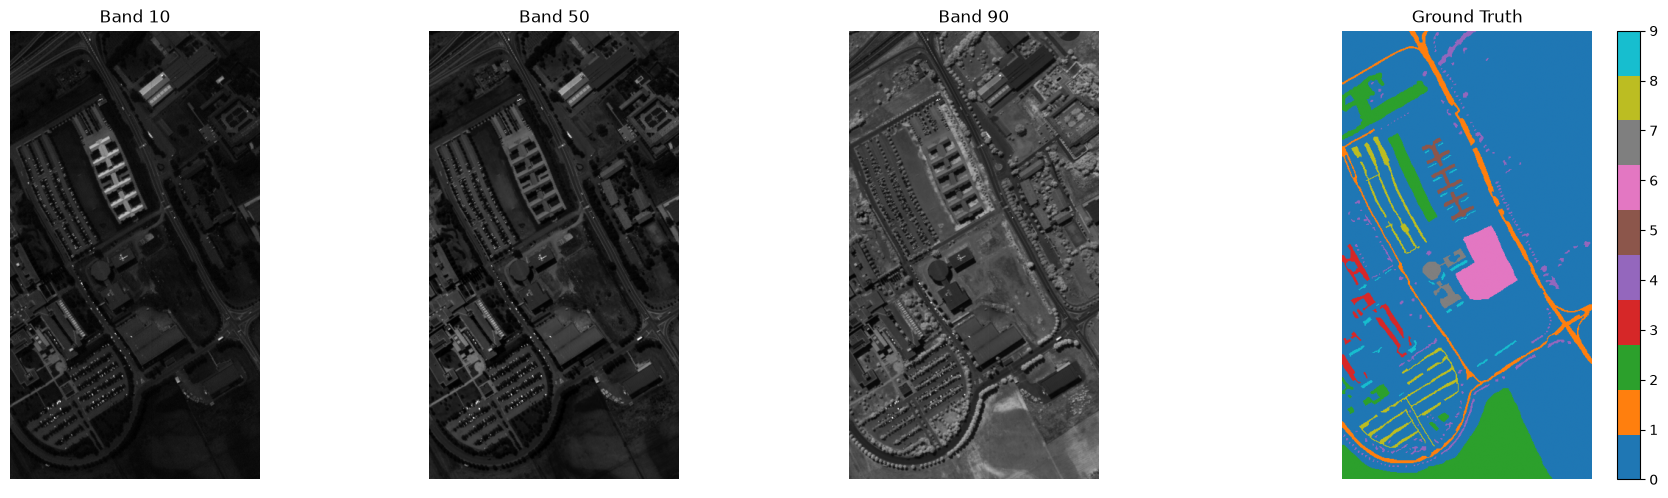

In [60]:
plot_spectral_bands_and_ground_truth(
    cube, ground_truth, BANDS_TO_SHOW, NUM_CLASSES
)

### Labeled Class Distribution

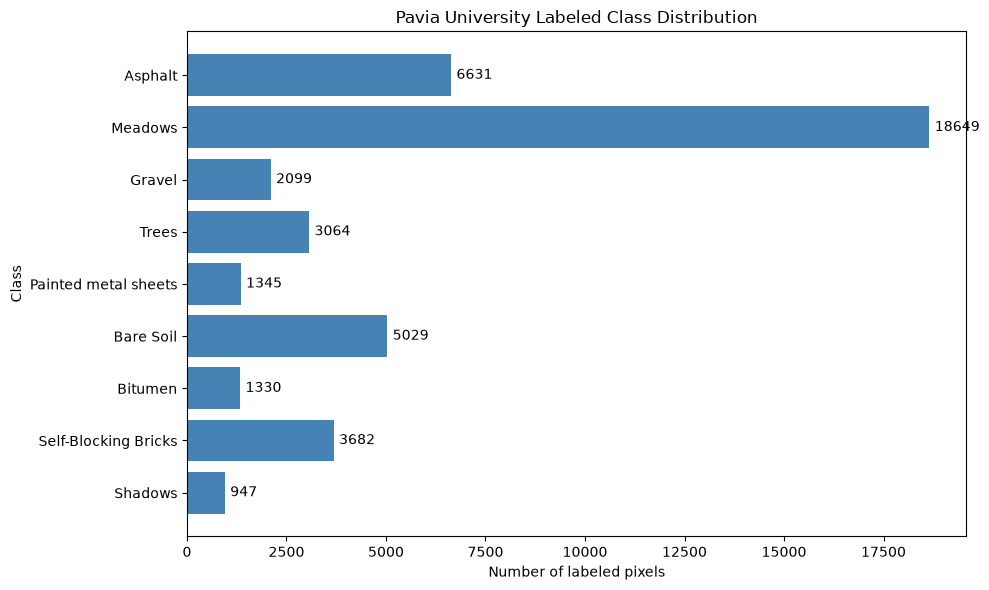

In [61]:
plot_class_distribution(labels, counts, class_names)

### Mean Spectral Signatures

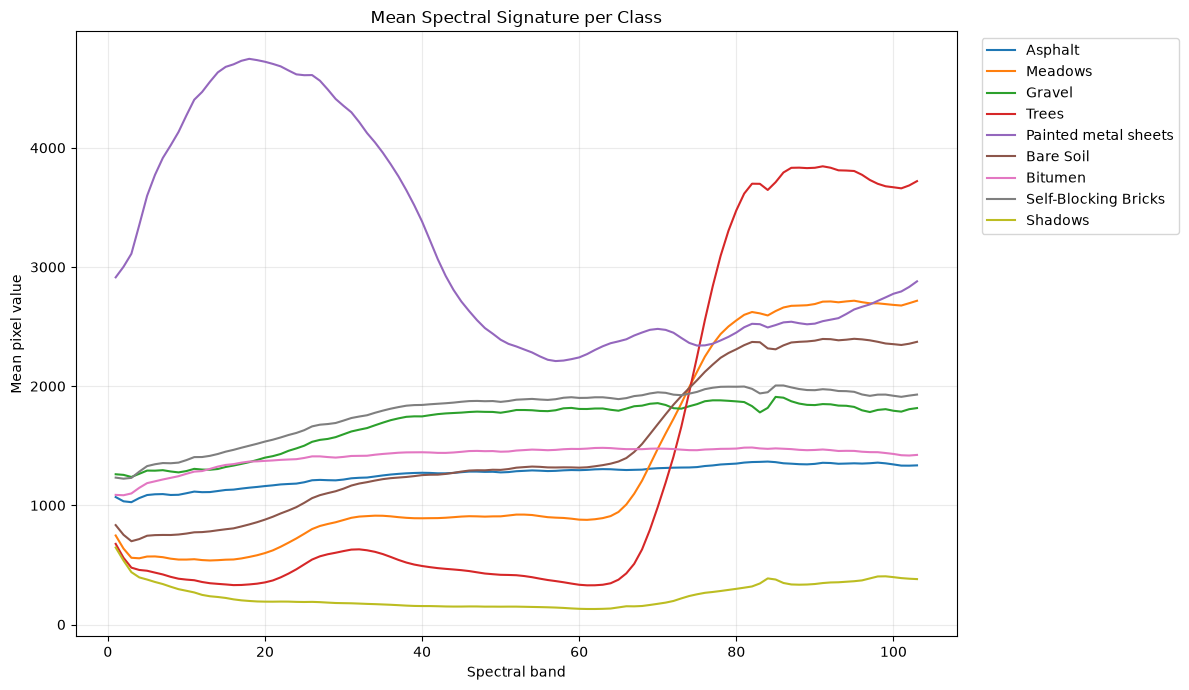

In [62]:
plot_mean_spectral_signatures(
    cube, ground_truth, LABELED_CLASS_IDS, class_names
)

### Coordinates By Class

In [63]:
coordinates_by_class = collect_coordinates_by_class(
    ground_truth, LABELED_CLASS_IDS
)

for label, coordinates in coordinates_by_class.items():
    expected_count = counts[labels == label].item()

    assert coordinates.shape == (expected_count, 2)
    print(
        f"{label}: {class_names[label]} - "
        f"{len(coordinates)} coordinates"
    )

total_coordinates = sum(
    len(coordinates)
    for coordinates in coordinates_by_class.values()
)

assert total_coordinates == np.count_nonzero(ground_truth)
print("Total labeled coordinates:", total_coordinates)

1: Asphalt - 6631 coordinates
2: Meadows - 18649 coordinates
3: Gravel - 2099 coordinates
4: Trees - 3064 coordinates
5: Painted metal sheets - 1345 coordinates
6: Bare Soil - 5029 coordinates
7: Bitumen - 1330 coordinates
8: Self-Blocking Bricks - 3682 coordinates
9: Shadows - 947 coordinates
Total labeled coordinates: 42776


### Few-Shot Coordinate Split

In [64]:
split_tables = create_few_shot_split(
    ground_truth,
    LABELED_CLASS_IDS,
    seed=SPLIT_SEED,
    train_samples_per_class=TRAIN_SAMPLES_PER_CLASS,
    validation_samples_per_class=VALIDATION_SAMPLES_PER_CLASS,
    split_type=DATA_SPLIT_TYPE,
    patch_radius=PATCH_RADIUS,
)
split_counts = split_counts_by_class(
    split_tables, LABELED_CLASS_IDS
)

for label in LABELED_CLASS_IDS:
    counts_for_label = split_counts[label]
    print(
        f"{label}: {class_names[label]} - "
        f"train {counts_for_label['train']}, "
        f"validation {counts_for_label['validation']}, "
        f"test {counts_for_label['test']}, "
        f"excluded {counts_for_label['excluded']}"
    )

1: Asphalt - train 10, validation 5, test 4902, excluded 1714
2: Meadows - train 10, validation 5, test 13523, excluded 5111
3: Gravel - train 10, validation 5, test 617, excluded 1467
4: Trees - train 10, validation 5, test 1994, excluded 1055
5: Painted metal sheets - train 10, validation 5, test 63, excluded 1267
6: Bare Soil - train 10, validation 5, test 1320, excluded 3694
7: Bitumen - train 10, validation 5, test 64, excluded 1251
8: Self-Blocking Bricks - train 10, validation 5, test 2405, excluded 1262
9: Shadows - train 10, validation 5, test 324, excluded 608


### Split Verification

In [65]:
verify_few_shot_split(
    split_tables,
    ground_truth,
    LABELED_CLASS_IDS,
    train_samples_per_class=TRAIN_SAMPLES_PER_CLASS,
    validation_samples_per_class=VALIDATION_SAMPLES_PER_CLASS,
    split_type=DATA_SPLIT_TYPE,
    patch_radius=PATCH_RADIUS,
    class_names=class_names,
)
expected_train_samples = len(split_tables[SplitName.TRAIN.value])
expected_validation_samples = len(
    split_tables[SplitName.VALIDATION.value]
)
expected_test_samples = len(split_tables[SplitName.TEST.value])
expected_excluded_samples = len(
    split_tables[SplitName.EXCLUDED.value]
)

print("Train coordinates:", expected_train_samples)
print("Validation coordinates:", expected_validation_samples)
print("Test coordinates:", expected_test_samples)
print("Excluded coordinates:", expected_excluded_samples)
print("All split checks passed.")

Train coordinates: 90
Validation coordinates: 45
Test coordinates: 25212
Excluded coordinates: 17429
All split checks passed.


### Save the Few-Shot Split

In [66]:
split_directory = project_root / "data" / "splits" / f"seed_{SPLIT_SEED}"
loaded_split_tables = save_and_verify_split(
    split_tables,
    ground_truth,
    split_directory,
    DATA_SPLIT_TYPE,
)

Saved 90 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_1\train_random_no_overlap.csv
Saved 45 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_1\validation_random_no_overlap.csv
Saved 25212 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_1\test_random_no_overlap.csv
Saved 17429 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_1\excluded_random_no_overlap.csv


### Reload and Verify the Saved Split

In [67]:
for split_name, split_table in loaded_split_tables.items():
    print(f"{split_name}: {len(split_table)} saved samples")

print(f"Saved split verified successfully for seed {SPLIT_SEED}.")

Verified train_random_no_overlap.csv: 90 samples
Verified validation_random_no_overlap.csv: 45 samples
Verified test_random_no_overlap.csv: 25212 samples
Verified excluded_random_no_overlap.csv: 17429 samples
Saved split verified successfully for seed 1.


### Border Analysis for Patch Extraction

In [68]:
padding_counts = count_padding_requirements(
    loaded_split_tables, ground_truth.shape, PATCH_RADIUS
)

for split_name, border_count in padding_counts.items():
    print(
        f"{split_name}: {border_count} of "
        f"{len(loaded_split_tables[split_name])} samples "
        "require padding"
    )

train: 5 of 90 samples require padding
validation: 1 of 45 samples require padding
test: 2646 of 25212 samples require padding
excluded: 649 of 17429 samples require padding


### Per-Band Min-Max Normalization

In [69]:
normalized_cube, band_min, band_max = normalize_per_band_min_max(
    cube
)

assert normalized_cube.shape == cube.shape
assert normalized_cube.dtype == np.float32
assert not np.shares_memory(normalized_cube, cube)
assert np.allclose(normalized_cube.min(axis=(0, 1)), 0.0)
assert np.allclose(normalized_cube.max(axis=(0, 1)), 1.0)

print("Normalized cube shape:", normalized_cube.shape)
print("Normalized cube dtype:", normalized_cube.dtype)
print("Normalized range:", normalized_cube.min(), normalized_cube.max())
print("Raw cube remains unchanged:", cube.dtype, cube.min(), cube.max())

Normalized cube shape: (610, 340, 103)
Normalized cube dtype: float32
Normalized range: 0.0 1.0
Raw cube remains unchanged: uint16 0 8000


### Reflect Padding

In [70]:
original_cube_shape = cube.shape
original_cube_dtype = cube.dtype

padded_cube = reflect_pad_spatially(
    normalized_cube, PATCH_RADIUS
)

expected_padded_shape = (
    normalized_cube.shape[0] + 2 * PATCH_RADIUS,
    normalized_cube.shape[1] + 2 * PATCH_RADIUS,
    normalized_cube.shape[2],
)
restored_normalized_cube = padded_cube[
    PATCH_RADIUS:-PATCH_RADIUS,
    PATCH_RADIUS:-PATCH_RADIUS,
    :,
]

assert cube.shape == original_cube_shape
assert cube.dtype == original_cube_dtype
assert padded_cube.shape == expected_padded_shape
assert padded_cube.dtype == normalized_cube.dtype
assert not np.shares_memory(normalized_cube, padded_cube)
assert np.array_equal(restored_normalized_cube, normalized_cube)

print("Normalized cube shape:", normalized_cube.shape)
print("Padded cube shape:", padded_cube.shape)
print("Raw cube remains unchanged.")

Normalized cube shape: (610, 340, 103)
Padded cube shape: (624, 354, 103)
Raw cube remains unchanged.


### Single Patch Extraction Check

In [71]:
sample_row, sample_column, sample_label = loaded_split_tables[
    "train"
][0]

sample_row = int(sample_row)
sample_column = int(sample_column)
sample_label = int(sample_label)

sample_patch = extract_patch(
    padded_cube, sample_row, sample_column, PATCH_SIZE
)

expected_patch_shape = (int(PATCH_SIZE), int(PATCH_SIZE), cube.shape[2])
center_spectrum = sample_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert sample_patch.shape == expected_patch_shape
assert np.array_equal(
    center_spectrum,
    normalized_cube[sample_row, sample_column, :],
)
assert ground_truth[sample_row, sample_column] == sample_label
assert sample_label != 0

print("Coordinate:", (sample_row, sample_column))
print("Target:", sample_label, class_names[sample_label])
print("Patch shape:", sample_patch.shape)
print("Center pixel and target verified.")

Coordinate: (356, 274)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Center pixel and target verified.


### Reusable Patch Extraction

In [72]:
all_saved_samples = np.vstack(list(loaded_split_tables.values()))
saved_rows = all_saved_samples[:, 0]
saved_columns = all_saved_samples[:, 1]

border_mask = (
    (saved_rows < PATCH_RADIUS)
    | (saved_rows >= ground_truth.shape[0] - PATCH_RADIUS)
    | (saved_columns < PATCH_RADIUS)
    | (saved_columns >= ground_truth.shape[1] - PATCH_RADIUS)
)
border_row, border_column, border_label = all_saved_samples[border_mask][0]
border_row = int(border_row)
border_column = int(border_column)
border_label = int(border_label)

border_patch = extract_patch(
    padded_cube, border_row, border_column, PATCH_SIZE
)
border_center = border_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert border_patch.shape == (
    int(PATCH_SIZE),
    int(PATCH_SIZE),
    cube.shape[2],
)
assert np.array_equal(
    border_center,
    normalized_cube[border_row, border_column, :],
)
assert ground_truth[border_row, border_column] == border_label

print("Border coordinate:", (border_row, border_column))
print("Target:", border_label, class_names[border_label])
print("Patch shape:", border_patch.shape)
print("Border patch verified.")

Border coordinate: (176, 4)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Border patch verified.


### PyTorch Patch Dataset

This portion of the code reads the CSV file with the saved split and from the normalized and padded data, estracts patch of the wanted size, adjust for model class logits.

We also convert numeric types to float32 and we use *ascontigousarray* for efficiency

In [73]:
datasets = create_patch_datasets(
    padded_cube, loaded_split_tables, PATCH_SIZE, NUM_CLASSES
)
train_dataset = datasets[SplitName.TRAIN.value]
validation_dataset = datasets[SplitName.VALIDATION.value]
test_dataset = datasets[SplitName.TEST.value]

example_patch, example_target = train_dataset[0]
example_row, example_column = train_dataset.coordinates[0]

assert len(train_dataset) == expected_train_samples
assert len(validation_dataset) == expected_validation_samples
assert len(test_dataset) == expected_test_samples
assert example_patch.shape == (
    cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_patch.dtype == torch.float32
assert example_target.dtype == torch.long
assert torch.equal(
    example_patch[:, PATCH_RADIUS, PATCH_RADIUS],
    torch.from_numpy(
        normalized_cube[example_row, example_column, :]
    ),
)

print("Dataset sizes:", len(train_dataset), len(validation_dataset), len(test_dataset))
print("Patch tensor shape:", tuple(example_patch.shape))
print("Target index:", example_target.item())
print("Original class label:", example_target.item() + 1)

Dataset sizes: 90 45 25212
Patch tensor shape: (103, 15, 15)
Target index: 0
Original class label: 1


### PyTorch DataLoaders

In [74]:
dataloaders = create_dataloaders(
    datasets,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    training_seed=TRAINING_SEED,
)
train_loader = dataloaders[SplitName.TRAIN.value]
validation_loader = dataloaders[SplitName.VALIDATION.value]
test_loader = dataloaders[SplitName.TEST.value]

batch_patches, batch_targets = next(iter(validation_loader))
train_class_counts = np.bincount(
    train_dataset.targets, minlength=NUM_CLASSES
)

assert batch_patches.shape == (
    BATCH_SIZE, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert batch_targets.shape == (BATCH_SIZE,)
assert batch_patches.dtype == torch.float32
assert batch_targets.dtype == torch.long
assert batch_targets.min() >= 0
assert batch_targets.max() < NUM_CLASSES
assert np.array_equal(
    train_class_counts,
    np.full(NUM_CLASSES, TRAIN_SAMPLES_PER_CLASS),
)

print("Batch shape:", tuple(batch_patches.shape))
print("Target shape:", tuple(batch_targets.shape))
print("Batches per epoch:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Training samples per class:", train_class_counts.tolist())

Batch shape: (32, 103, 15, 15)
Target shape: (32,)
Batches per epoch: 3
Validation batches: 2
Test batches: 788
Training samples per class: [10, 10, 10, 10, 10, 10, 10, 10, 10]


## CNN-Only Baseline

### Multiscale CNN Block

In [75]:
cnn_block = MultiscaleCNNBlock(FEATURE_CHANNELS)
cnn_block.eval()

dummy_features = torch.randn(
    2, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
with torch.no_grad():
    dummy_output = cnn_block(dummy_features)

assert dummy_output.shape == dummy_features.shape

print("Input shape:", tuple(dummy_features.shape))
print("Output shape:", tuple(dummy_output.shape))
print("CNN block preserves channel and spatial dimensions.")

Input shape: (2, 128, 15, 15)
Output shape: (2, 128, 15, 15)
CNN block preserves channel and spatial dimensions.


### CNN-Only Classifier

In [76]:
cnn_baseline = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
cnn_baseline.eval()

example_batch = example_patch.unsqueeze(0)
with torch.no_grad():
    projected_features = cnn_baseline.input_projection(example_batch)
    example_logits = cnn_baseline(example_batch)

assert projected_features.shape == (
    1, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_logits.shape == (1, NUM_CLASSES)

print("Input shape:", tuple(example_batch.shape))
print("Projected feature shape:", tuple(projected_features.shape))
print("Logits shape:", tuple(example_logits.shape))

Input shape: (1, 103, 15, 15)
Projected feature shape: (1, 128, 15, 15)
Logits shape: (1, 9)


### Forward and Backward Sanity Check

In [77]:
sanity_indices = [
    np.flatnonzero(train_dataset.targets == class_index)[0]
    for class_index in range(NUM_CLASSES)
]
sanity_samples = [
    train_dataset[int(index)] for index in sanity_indices
]
sanity_patches = torch.stack([sample[0] for sample in sanity_samples])
sanity_targets = torch.stack([sample[1] for sample in sanity_samples])

torch.manual_seed(TRAINING_SEED)
sanity_model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
sanity_model.train()

criterion = nn.CrossEntropyLoss()
sanity_logits = sanity_model(sanity_patches)
sanity_loss = criterion(sanity_logits, sanity_targets)
sanity_loss.backward()

gradients = [
    parameter.grad
    for parameter in sanity_model.parameters()
    if parameter.grad is not None
]
gradient_norm = sum(gradient.norm().item() for gradient in gradients)

assert sanity_patches.shape == (
    NUM_CLASSES, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert torch.equal(sanity_targets, torch.arange(NUM_CLASSES))
assert sanity_logits.shape == (NUM_CLASSES, NUM_CLASSES)
assert torch.isfinite(sanity_loss)
assert gradients
assert all(torch.isfinite(gradient).all() for gradient in gradients)
assert gradient_norm > 0

sanity_model.zero_grad(set_to_none=True)

print("Sanity batch shape:", tuple(sanity_patches.shape))
print("Targets:", sanity_targets.tolist())
print("Logits shape:", tuple(sanity_logits.shape))
print("Loss:", sanity_loss.item())
print("Gradient norm:", gradient_norm)
print("Forward and backward checks passed.")

Sanity batch shape: (9, 103, 15, 15)
Targets: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Logits shape: (9, 9)
Loss: 2.1906821727752686
Gradient norm: 4.492813685823263
Forward and backward checks passed.


### Small-Batch Overfitting Test

In [78]:
torch.manual_seed(TRAINING_SEED)
overfit_model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
overfit_result = run_small_batch_overfit_check(
    overfit_model,
    sanity_patches,
    sanity_targets,
    learning_rate=OVERFIT_LEARNING_RATE,
    min_steps=OVERFIT_MIN_STEPS,
    max_steps=OVERFIT_MAX_STEPS,
    target_loss=OVERFIT_TARGET_LOSS,
)

print("Steps:", overfit_result["steps"])
print("Initial loss:", overfit_result["initial_loss"])
print("Final loss:", overfit_result["final_loss"])
print("Final accuracy:", overfit_result["final_accuracy"])
print("Small-batch overfitting test passed.")

Steps: 50
Initial loss: 2.1906821727752686
Final loss: 0.00013328413479030132
Final accuracy: 1.0
Small-batch overfitting test passed.


## CNN-Only Training

### Training Configuration

In [79]:
device = configure_reproducibility(TRAINING_SEED)

model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
).to(device)
run_name = (
    RunMode.FULL.value
    if RUN_FULL_TRAINING
    else RunMode.SMOKE.value
)
epochs_to_run = (
    EPOCHS if RUN_FULL_TRAINING else SMOKE_TEST_EPOCHS
)
checkpoint_path = build_checkpoint_path(
    project_root / "outputs" / "checkpoints",
    model_name="cnn",
    run_name=run_name,
    patch_size=PATCH_SIZE,
    epochs=epochs_to_run,
    feature_channels=FEATURE_CHANNELS,
    scheduling_type=LR_SCHEDULING,
    split_seed=SPLIT_SEED,
    split_type=DATA_SPLIT_TYPE,
    training_seed=TRAINING_SEED,
)
experiment_configuration = {
    "dataset": "Pavia University",
    "model": model.__class__.__name__,
    "split_seed": SPLIT_SEED,
    "data_split_type": DATA_SPLIT_TYPE.value,
    "training_seed": TRAINING_SEED,
    "feature_channels": FEATURE_CHANNELS,
    "patch_size": int(PATCH_SIZE),
    "num_classes": NUM_CLASSES,
    "run_mode": run_name,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "lr_scheduling": LR_SCHEDULING.value,
    "epochs_requested": epochs_to_run,
    "normalization": "per_band_min_max_full_scene",
    "padding": "reflect",
}
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Device:", device)
print("Epochs:", epochs_to_run)
print("Learning rate:", LEARNING_RATE)
print("LR scheduling:", LR_SCHEDULING.value)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Trainable parameters:", trainable_parameters)
print("Checkpoint:", checkpoint_path)

Device: cpu
Epochs: 150
Learning rate: 8e-05
LR scheduling: fixed
Data split: random_no_overlap
Trainable parameters: 982921
Checkpoint: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\outputs\checkpoints\cnn_full_p15_e150_f128_lrfixed_split1_random_no_overlap_train100.pt


### Model Training

In [81]:
training_result = fit_model(
    model,
    train_loader,
    validation_loader,
    device,
    epochs=epochs_to_run,
    learning_rate=LEARNING_RATE,
    scheduling_type=LR_SCHEDULING,
    checkpoint_path=checkpoint_path,
    checkpoint_metadata=experiment_configuration,
)
history = training_result["history"]

print("Best epoch:", training_result["best_epoch"])
print(
    "Best validation loss:",
    training_result["best_validation_loss"],
)
print("Checkpoint saved to:", checkpoint_path)

Epoch 001/150 | train loss 2.1475, acc 0.1222 | val loss 2.1924, acc 0.1111 | lr 8.00e-05
Epoch 010/150 | train loss 1.3276, acc 0.5222 | val loss 1.9548, acc 0.4000 | lr 8.00e-05
Epoch 020/150 | train loss 0.8410, acc 0.7222 | val loss 1.1119, acc 0.7556 | lr 8.00e-05
Epoch 030/150 | train loss 0.5359, acc 0.8556 | val loss 0.8214, acc 0.7111 | lr 8.00e-05
Epoch 040/150 | train loss 0.3477, acc 0.9333 | val loss 0.7677, acc 0.6667 | lr 8.00e-05
Epoch 050/150 | train loss 0.2264, acc 0.9889 | val loss 0.6426, acc 0.7333 | lr 8.00e-05
Epoch 060/150 | train loss 0.1825, acc 0.9778 | val loss 0.5742, acc 0.7778 | lr 8.00e-05
Epoch 070/150 | train loss 0.1283, acc 0.9889 | val loss 0.5827, acc 0.8222 | lr 8.00e-05
Epoch 080/150 | train loss 0.0788, acc 0.9889 | val loss 0.4683, acc 0.8222 | lr 8.00e-05
Epoch 090/150 | train loss 0.0846, acc 0.9889 | val loss 0.9701, acc 0.6667 | lr 8.00e-05
Epoch 100/150 | train loss 0.0576, acc 0.9889 | val loss 0.5108, acc 0.8667 | lr 8.00e-05
Epoch 110/

### Training Curves

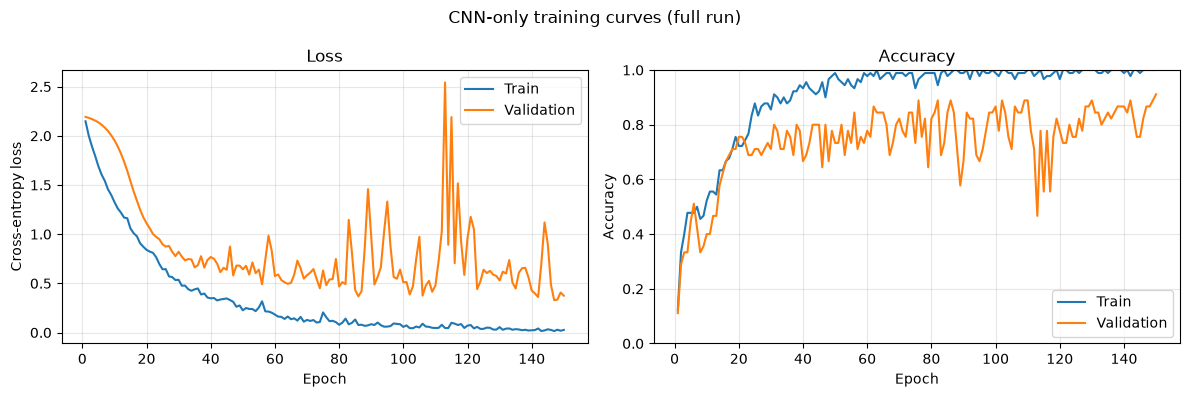

In [82]:
plot_training_curves(history, run_name)

## CNN-Only Evaluation

In [83]:
evaluation_result = evaluate_checkpoint(
    model,
    test_loader,
    checkpoint_path,
    device,
    NUM_CLASSES,
    progress_every=EVALUATION_PROGRESS_EVERY,
    progress_label="Test evaluation",
)
best_checkpoint = evaluation_result["checkpoint"]
test_targets = evaluation_result["targets"]
test_predictions = evaluation_result["predictions"]

assert len(test_targets) == len(test_dataset)
print("Loaded checkpoint epoch:", best_checkpoint["epoch"])
print("Checkpoint validation loss:", best_checkpoint["validation_loss"])
print("Test predictions:", len(test_predictions))

Loaded checkpoint epoch: 147
Checkpoint validation loss: 0.32915136184957294
Test predictions: 25212


### Test Metrics

OA: 0.8051
AA: 0.8412
Kappa: 0.7243
Per-class accuracy:
  1 Asphalt: 0.8091
  2 Meadows: 0.7790
  3 Gravel: 0.4117
  4 Trees: 0.8506
  5 Painted metal sheets: 1.0000
  6 Bare Soil: 0.8015
  7 Bitumen: 1.0000
  8 Self-Blocking Bricks: 0.9805
  9 Shadows: 0.9383


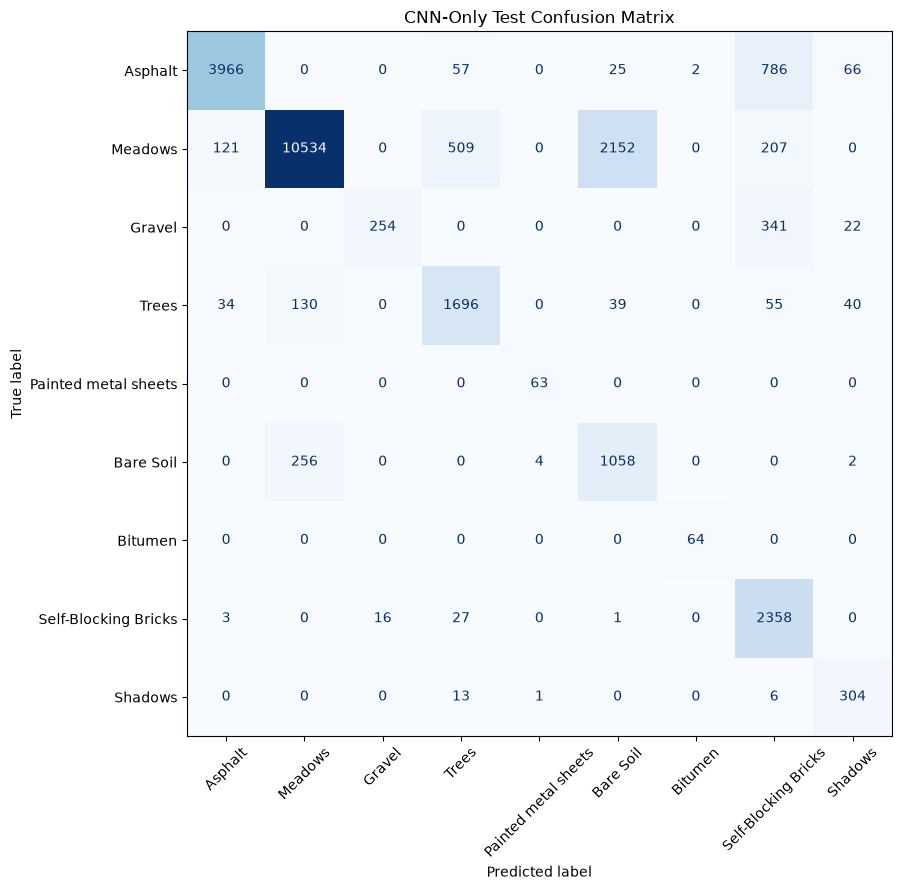

In [84]:
test_metrics = evaluation_result["metrics"]
confusion = test_metrics["confusion_matrix"]
per_class_accuracy = test_metrics["per_class_accuracy"]
overall_accuracy = test_metrics["overall_accuracy"]
average_accuracy = test_metrics["average_accuracy"]
kappa = test_metrics["kappa"]

print(f"OA: {overall_accuracy:.4f}")
print(f"AA: {average_accuracy:.4f}")
print(f"Kappa: {kappa:.4f}")
print("Per-class accuracy:")
for class_index, class_accuracy in enumerate(per_class_accuracy):
    original_label = class_index + 1
    print(
        f"  {original_label} {class_names[original_label]}: "
        f"{class_accuracy:.4f}"
    )

evaluation_report_path = (
    project_root / "outputs" / "results"
    / f"{checkpoint_path.stem}.json"
)
evaluation_report = build_evaluation_report(
    experiment_configuration,
    checkpoint_path,
    evaluation_result,
    class_names,
)
if SAVE_EVALUATION_REPORT:
    save_evaluation_report(
        evaluation_report_path, evaluation_report
    )
    print("Evaluation report saved to:", evaluation_report_path)

display_names = [class_names[label] for label in LABELED_CLASS_IDS]
plot_confusion_matrix(confusion, display_names)

### Normalized Confusion Matrix

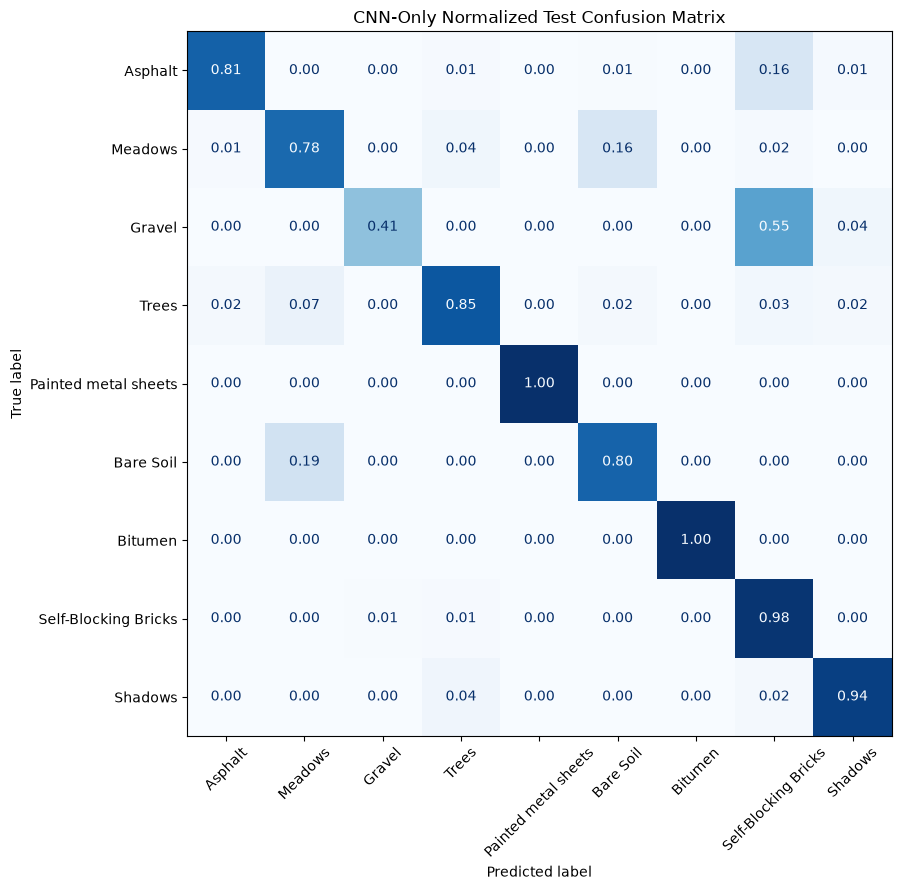

In [85]:
plot_confusion_matrix(
    confusion, display_names, normalized=True
)

### CNN-Only Classification Map

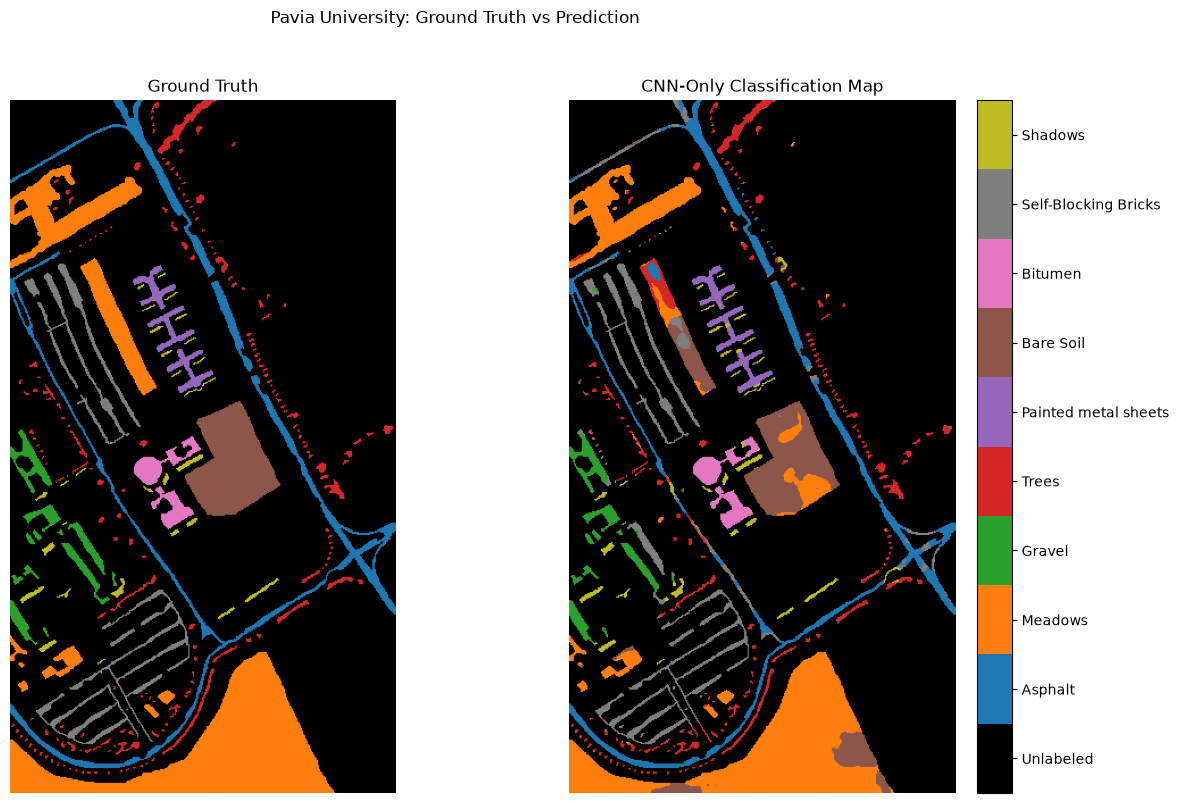

Mapped labeled pixels: 42776
Unlabeled pixels kept as background: 164624


In [86]:
classification_map = build_classification_map(
    model,
    device,
    ground_truth,
    padded_cube,
    loaded_split_tables,
    test_predictions,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
labeled_mask = ground_truth != PaviaClass.UNLABELED
plot_classification_map(
    ground_truth, classification_map, class_names, NUM_CLASSES
)

print("Mapped labeled pixels:", np.count_nonzero(labeled_mask))
print("Unlabeled pixels kept as background:", (~labeled_mask).sum())